# NOTEBOOK 04 - TRADUÇÃO E FILTRO DOS COMENTÁRIOS

## Disciplina: IMD1151 - Ciência de Dados

### Objetivos:
1. Usar LLM para traduzir os comentários para uma linguagem só
2. Aplicar filtro de qualidade para manter apenas reviews substantivas


In [ ]:
# Instalar bibliotecas necessárias
!pip install transformers sentencepiece torch tqdm langdetect --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
from langdetect import detect, LangDetectException
from tqdm import tqdm
import warnings
import torch
import re

warnings.filterwarnings('ignore')
tqdm.pandas()

# Verificar dispositivo
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🖥️  Dispositivo: {device}")

# Configurar visualizações
plt.style.use('default')
sns.set_palette("husl")

🖥️  Dispositivo: cuda


In [ ]:
df_translated = pd.read_csv(
    'cyberpunk_reviews.csv',
    encoding='latin-1',
    engine='python',
    on_bad_lines='skip'
)

RECALCULANDO AS ESTATISTICAS DOS COMENTÁRIOS SOBRE O TEXTO AGORA TRADUZIDO

In [ ]:
df_translated['word_count'] = df_translated['review_text_en'].astype(str).str.split().str.len()
df_translated['char_count'] = df_translated['review_text_en'].astype(str).str.len()
df_translated['avg_word_length'] = df_translated['char_count'] / df_translated['word_count']

print("Estatísticas do texto em inglês")
print(df_translated[['word_count', 'char_count', 'avg_word_length']].describe())

Estatísticas do texto em inglês
         word_count    char_count  avg_word_length
count  41557.000000  41557.000000     41557.000000
mean      26.891547    174.689968         6.056832
std       54.213434    365.837504         5.294811
min        1.000000      2.000000         1.998039
25%        5.000000     26.000000         5.375000
50%       10.000000     60.000000         6.133333
75%       25.000000    160.000000         6.718750
max     1342.000000   7978.000000      1023.000000


In [ ]:
df_translated['review_length_category'] = pd.cut(
    df_translated['word_count'],
    bins=[0, 5, 20, 100, 500, float('inf')],
    labels=['Muito Curta (<5)', 'Curta (5-20)', 'Média (20-100)',
            'Longa (100-500)', 'Muito Longa (500+)']
)

print("DISTRIBUIÇÃO POR TAMANHO:")
print(df_translated['review_length_category'].value_counts().sort_index())

DISTRIBUIÇÃO POR TAMANHO:
review_length_category
Muito Curta (<5)      12885
Curta (5-20)          16432
Média (20-100)         9902
Longa (100-500)        2251
Muito Longa (500+)       87
Name: count, dtype: int64


REALIZANDO O FILTRO NOS COMENTÁRIOS PARA REALIZAR ANÁLISE DOS TEXTOS NOVAMENTE SEM OS OUTLIERS

In [ ]:
MIN_WORDS_EN = 15
MAX_WORDS_EN = 300
MIN_CHARS_EN = 100
MAX_CHARS_EN = 2000


print(f"Filtros aplicados:")
print(f"Palavras: {MIN_WORDS_EN} a {MAX_WORDS_EN}")
print(f"Caracteres: {MIN_CHARS_EN} a {MAX_CHARS_EN}")

df_filtered = df_translated[
    (df_translated['word_count'] >= MIN_WORDS_EN) &
    (df_translated['word_count'] <= MAX_WORDS_EN) &
    (df_translated['char_count'] >= MIN_CHARS_EN) &
    (df_translated['char_count'] <= MAX_CHARS_EN)
].copy()

total_original = len(df_translated)
total_filtered = len(df_filtered)
removed = total_original - total_filtered
retention_rate = (total_filtered / total_original) * 100

print(f"Total original: {total_original:,} reviews")
print(f"Mantidas: {total_filtered:,} reviews ({retention_rate:.1f}%)")
print(f"Removidas: {removed:,} reviews ({100-retention_rate:.1f}%)")

print(f"Estatísticas das reviews FILTRADAS:")
print(df_filtered[['word_count', 'char_count', 'avg_word_length']].describe())

Filtros aplicados:
Palavras: 15 a 300
Caracteres: 100 a 2000
Total original: 41,557 reviews
Mantidas: 14,468 reviews (34.8%)
Removidas: 27,089 reviews (65.2%)
Estatísticas das reviews FILTRADAS:
         word_count    char_count  avg_word_length
count  14468.000000  14468.000000     14468.000000
mean      54.148673    356.464888         6.522244
std       47.714782    323.616017         0.590995
min       15.000000    100.000000         3.491124
25%       23.000000    145.000000         6.144381
50%       36.000000    231.000000         6.520833
75%       66.000000    433.000000         6.880686
max      300.000000   1993.000000        11.653543


In [ ]:
print("DISTRIBUIÇÃO POR TAMANHO:")
print(df_filtered['review_length_category'].value_counts().sort_index())

DISTRIBUIÇÃO POR TAMANHO:
review_length_category
Muito Curta (<5)         0
Curta (5-20)          2610
Média (20-100)        9894
Longa (100-500)       1964
Muito Longa (500+)       0
Name: count, dtype: int64


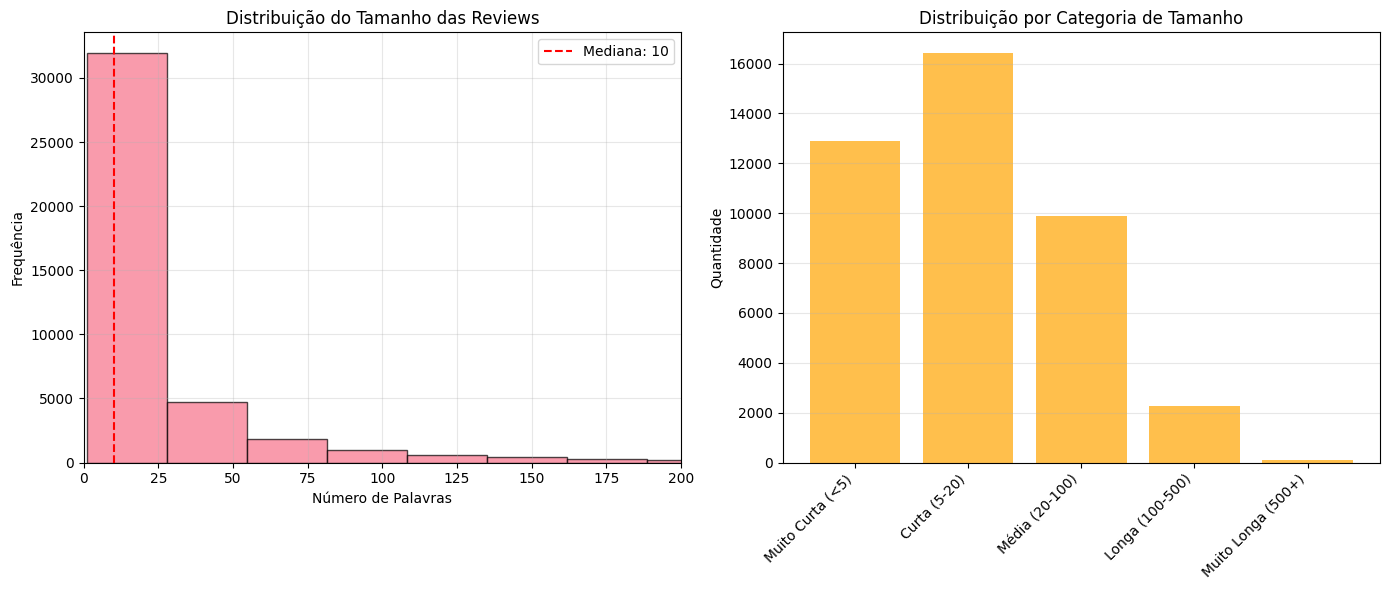

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribuição de tamanho do comentário
axes[0].hist(df_translated['word_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df_translated['word_count'].median(), color='red', linestyle='--',
                label=f'Mediana: {df_translated["word_count"].median():.0f}')
axes[0].set_xlabel('Número de Palavras')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição do Tamanho das Reviews')
axes[0].legend()
axes[0].set_xlim(0, 200)
axes[0].grid(alpha=0.3)

# Categorias de tamanho
size_counts = df_translated['review_length_category'].value_counts().sort_index()
axes[1].bar(range(len(size_counts)), size_counts.values, alpha=0.7, color='orange')
axes[1].set_xticks(range(len(size_counts)))
axes[1].set_xticklabels(size_counts.index, rotation=45, ha='right')
axes[1].set_ylabel('Quantidade')
axes[1].set_title('Distribuição por Categoria de Tamanho')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

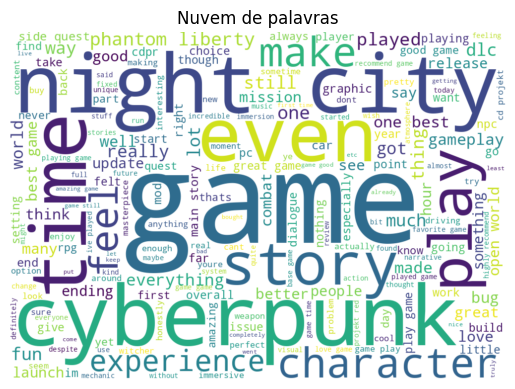

In [ ]:
from wordcloud import WordCloud

texto = ' '.join(df_filtered['review_text_en'].astype(str))
wordcloud = WordCloud(width=1000, height=700, background_color='white').generate(texto)

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Nuvem de palavras")
plt.show()

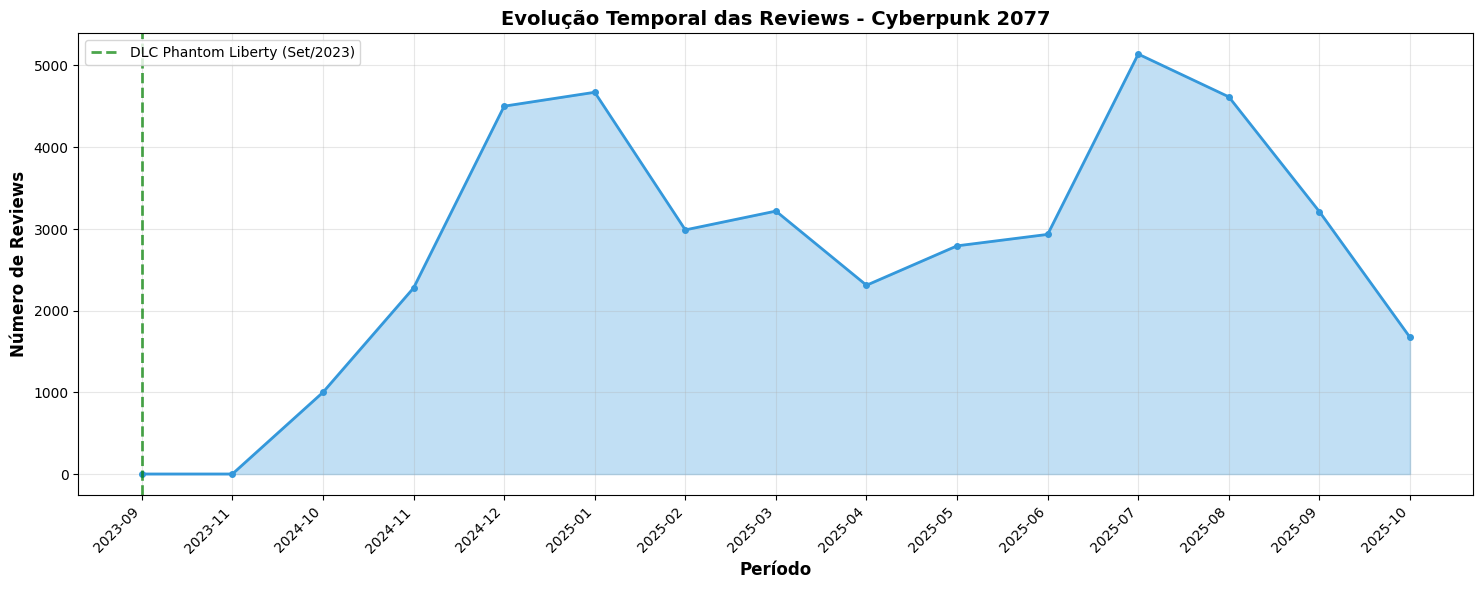

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(18, 6))

reviews_per_month = df_translated.groupby('year_month').size()

dlc_date = pd.Period('2023-09', 'M')
reviews_per_month.index = pd.PeriodIndex(reviews_per_month.index, freq='M')
reviews_per_month = reviews_per_month[reviews_per_month.index >= dlc_date]



ax1.plot(reviews_per_month.index.astype(str), reviews_per_month.values,
         linewidth=2, marker='o', markersize=4, color='#3498db')
ax1.fill_between(range(len(reviews_per_month)), reviews_per_month.values,
                 alpha=0.3, color='#3498db')

if dlc_date in reviews_per_month.index:
    dlc_idx = list(reviews_per_month.index).index(dlc_date)
    ax1.axvline(dlc_idx, color='green', linestyle='--', linewidth=2, alpha=0.7,
                label='DLC Phantom Liberty (Set/2023)')

ax1.set_xlabel('Período', fontsize=12, fontweight='bold')
ax1.set_ylabel('Número de Reviews', fontsize=12, fontweight='bold')
ax1.set_title('Evolução Temporal das Reviews - Cyberpunk 2077', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

step = max(1, len(reviews_per_month) // 20)
if step == 0: step = 1

ax1.set_xticks(range(0, len(reviews_per_month), step))
ax1.set_xticklabels([str(x) for x in reviews_per_month.index[::step]], rotation=45, ha='right')

plt.show()

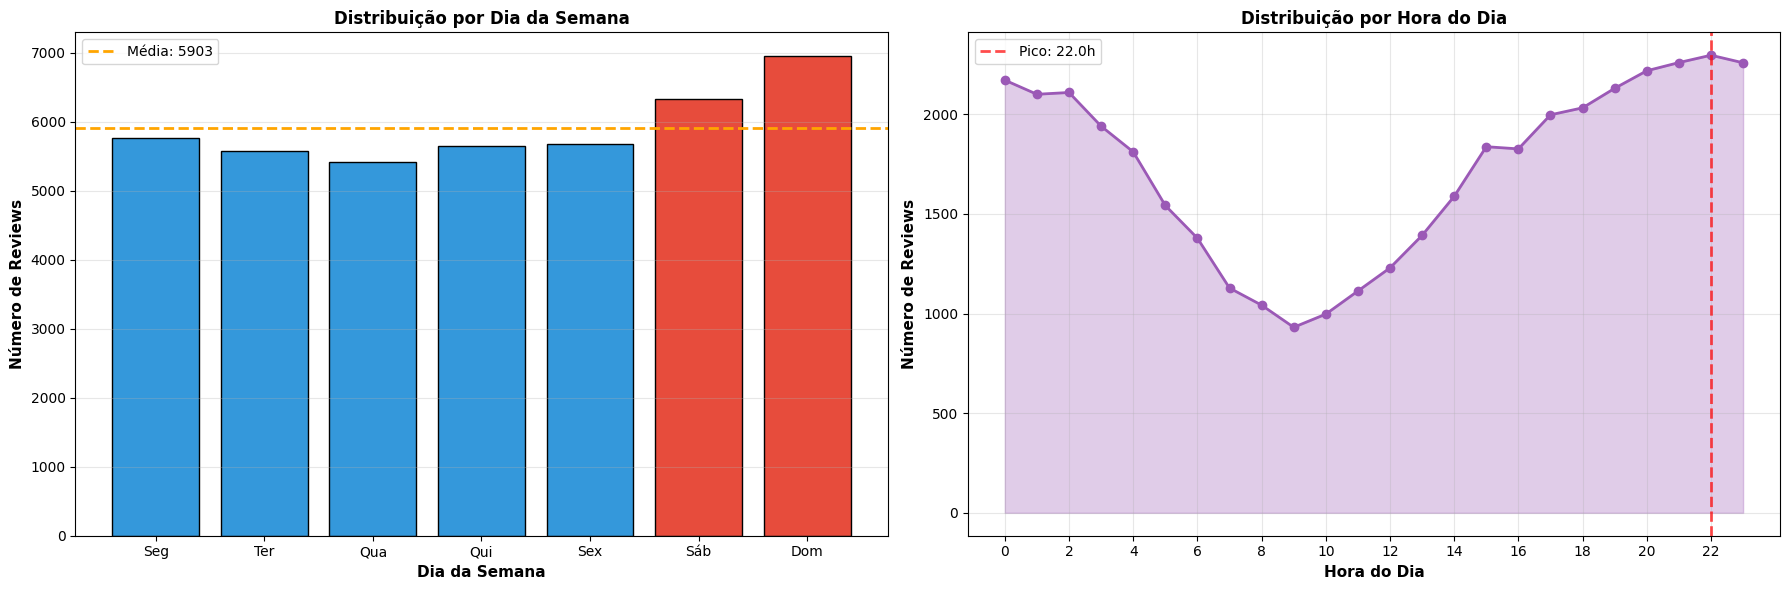

In [ ]:
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(18, 6))

# Distribuição por Dia da Semana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_abbr = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sáb', 'Dom']

day_counts = df_translated['day_of_week'].value_counts()
day_counts = day_counts.reindex(day_order)

colors_day = ['#e74c3c' if day in ['Saturday', 'Sunday'] else '#3498db' for day in day_order]

ax5.bar(day_abbr, day_counts.values, color=colors_day, edgecolor='black', linewidth=1)
ax5.set_xlabel('Dia da Semana', fontsize=11, fontweight='bold')
ax5.set_ylabel('Número de Reviews', fontsize=11, fontweight='bold')
ax5.set_title('Distribuição por Dia da Semana', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

mean_line = day_counts.mean()
ax5.axhline(y=mean_line, color='orange', linestyle='--', linewidth=2, label=f'Média: {mean_line:.0f}')
ax5.legend()

# Distribuição por Hora do Dia
hour_counts = df_translated['hour'].value_counts().sort_index()

ax6.plot(hour_counts.index, hour_counts.values, marker='o', linewidth=2, markersize=6, color='#9b59b6')
ax6.fill_between(hour_counts.index, hour_counts.values, alpha=0.3, color='#9b59b6')

peak_hour = hour_counts.idxmax()
ax6.axvline(x=peak_hour, color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'Pico: {peak_hour}h')

ax6.set_xlabel('Hora do Dia', fontsize=11, fontweight='bold')
ax6.set_ylabel('Número de Reviews', fontsize=11, fontweight='bold')
ax6.set_title('Distribuição por Hora do Dia', fontsize=12, fontweight='bold')
ax6.set_xticks(range(0, 24, 2))
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


ANÁLISE UNIVARIADA PÓS FILTRO DOS COMENTÁRIOS

Distribuição de Sentimento:
Positivas (Recomenda): 38,788 (93.3%)
Negativas (Não recomenda): 2,542 (6.1%)


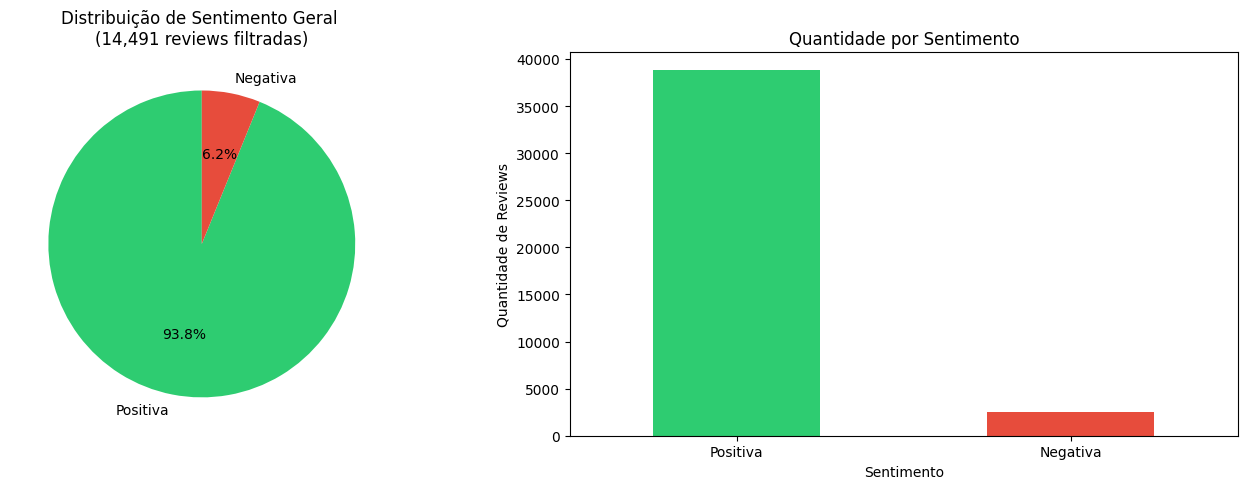

In [ ]:
df_translated['is_recommended'] = df_translated['is_recommended'].map({
    'True': True,
    'False': False
})

sentiment_counts = df_translated['is_recommended'].value_counts()
total = len(df_translated)

print(f"Distribuição de Sentimento:")
print(f"Positivas (Recomenda): {sentiment_counts[True]:,} ({sentiment_counts[True]/total*100:.1f}%)")
print(f"Negativas (Não recomenda): {sentiment_counts[False]:,} ({sentiment_counts[False]/total*100:.1f}%)")

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(sentiment_counts.values, labels=['Positiva', 'Negativa'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Distribuição de Sentimento Geral \n(14,491 reviews filtradas)')

sentiment_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_xlabel('Sentimento')
axes[1].set_ylabel('Quantidade de Reviews')
axes[1].set_title('Quantidade por Sentimento')
axes[1].set_xticklabels(['Positiva', 'Negativa'], rotation=0)

plt.tight_layout()
plt.show()


Estatísticas de Tempo de Jogo:
       total_playtime_hours  playtime_at_review_hours
count          41325.000000              41325.000000
mean             144.381761                104.229307
std              199.108922                168.071629
min                0.083333                  0.083333
25%               52.533333                 26.433333
50%               98.216667                 62.783333
75%              169.600000                124.733333
max            10607.433333               8836.433333


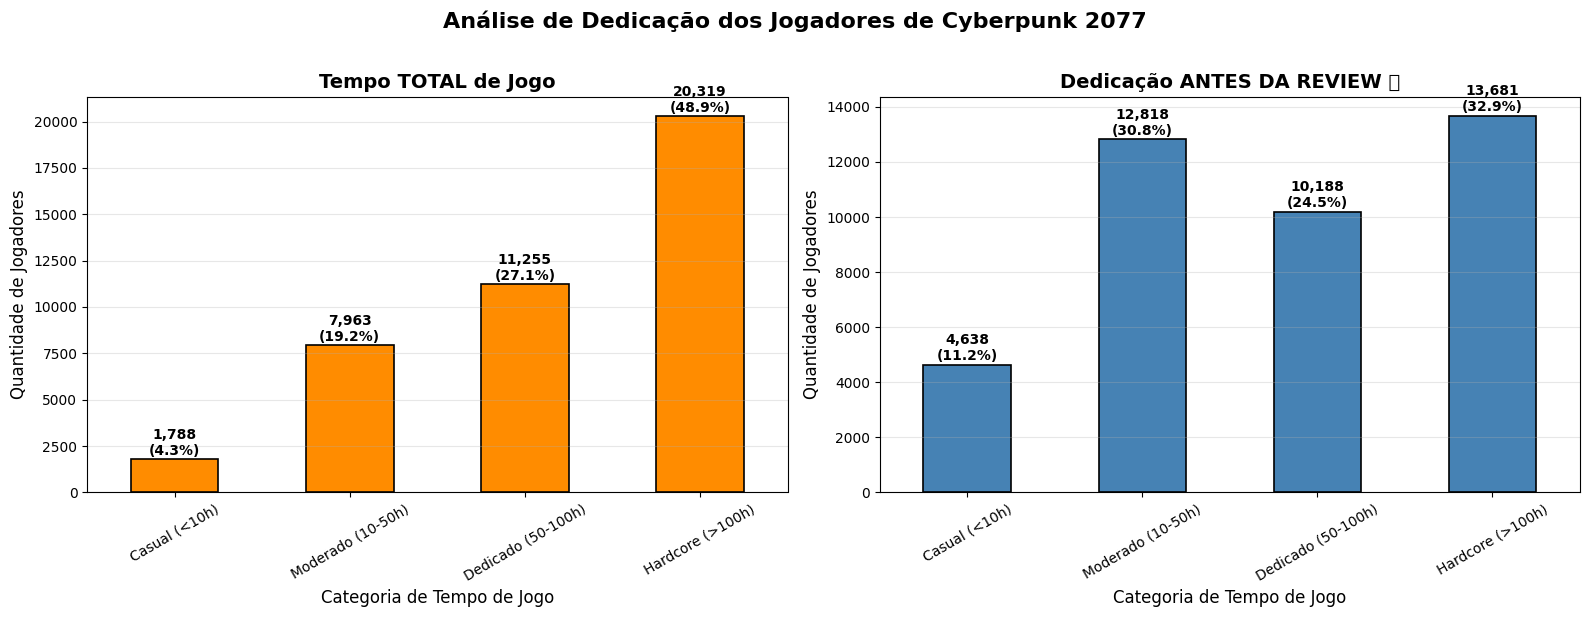


CONTINUIDADE:
Jogadores continuaram jogando significativamente após fazer a review
(média de 40.2h adicionais após comentar)


In [ ]:
df_translated['total_playtime_hours'] = pd.to_numeric(
    df_translated['total_playtime_hours'], errors='coerce'
)

df_translated['playtime_at_review_hours'] = pd.to_numeric(
    df_translated['playtime_at_review_hours'], errors='coerce'
)

# Mostrar estatísticas
print("Estatísticas de Tempo de Jogo:")
print(df_translated[['total_playtime_hours', 'playtime_at_review_hours']].describe())


# ----------------------------------------------------
# 2) Categorizar tempo de jogo
# ----------------------------------------------------
def categorize_playtime(hours):
    if pd.isna(hours):
        return 'Desconhecido'
    if hours < 10:
        return 'Casual (<10h)'
    elif hours < 50:
        return 'Moderado (10-50h)'
    elif hours < 100:
        return 'Dedicado (50-100h)'
    else:
        return 'Hardcore (>100h)'

df_translated['playtime_category_total'] = df_translated['total_playtime_hours'].apply(categorize_playtime)
df_translated['playtime_category_at_review'] = df_translated['playtime_at_review_hours'].apply(categorize_playtime)


# ----------------------------------------------------
# 3) Distribuições
# ----------------------------------------------------
playtime_dist_total = df_translated['playtime_category_total'].value_counts()
playtime_dist_review = df_translated['playtime_category_at_review'].value_counts()

categories_order = ['Casual (<10h)', 'Moderado (10-50h)', 'Dedicado (50-100h)', 'Hardcore (>100h)']


# ----------------------------------------------------
# 4) GRÁFICOS
# ----------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Gráfico 1: Tempo TOTAL ----
playtime_dist_total.reindex(categories_order, fill_value=0).plot(
    kind='bar', ax=axes[0], color='darkorange', edgecolor='black', linewidth=1.2
)

axes[0].set_xlabel('Categoria de Tempo de Jogo', fontsize=12)
axes[0].set_ylabel('Quantidade de Jogadores', fontsize=12)
axes[0].set_title('Tempo TOTAL de Jogo', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(axis='y', alpha=0.3)

# valores nas barras
for i, (cat, value) in enumerate(playtime_dist_total.reindex(categories_order, fill_value=0).items()):
    if value > 0:
        axes[0].text(i, value + 50, f'{value:,}\n({value/len(df_translated)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')


# ---- Gráfico 2: Tempo NO MOMENTO DA REVIEW ----
playtime_dist_review.reindex(categories_order, fill_value=0).plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black', linewidth=1.2
)

axes[1].set_xlabel('Categoria de Tempo de Jogo', fontsize=12)
axes[1].set_ylabel('Quantidade de Jogadores', fontsize=12)
axes[1].set_title('Dedicação ANTES DA REVIEW ⭐', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)

# valores nas barras
for i, (cat, value) in enumerate(playtime_dist_review.reindex(categories_order, fill_value=0).items()):
    if value > 0:
        axes[1].text(i, value + 50, f'{value:,}\n({value/len(df_translated)*100:.1f}%)',
                     ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Análise de Dedicação dos Jogadores de Cyberpunk 2077',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


# ----------------------------------------------------
# 5) Diferença de tempo total vs. tempo na review
# ----------------------------------------------------
diff_hours = df_translated['total_playtime_hours'].mean() - df_translated['playtime_at_review_hours'].mean()

print("\nCONTINUIDADE:")
if diff_hours > 5:
    print(f"Jogadores continuaram jogando significativamente após fazer a review")
    print(f"(média de {diff_hours:.1f}h adicionais após comentar)")
elif diff_hours > 1:
    print(f"Jogadores jogaram um pouco mais após a review ({diff_hours:.1f}h)")
else:
    print("Reviews foram feitas próximo ao tempo total atual de jogo")

In [ ]:
df_translated['helpful_votes'] = pd.to_numeric(
    df_translated['helpful_votes'], errors='coerce'
)

print(f"Estatísticas de Helpful Votes:")
print(df_translated['helpful_votes'].describe())

# Reviews com mais vots
top_helpful = df_translated.nlargest(5, 'helpful_votes')[['helpful_votes', 'is_recommended', 'word_count', 'review_text_en']]

print(f"\n\nTop 5 Reviews mais votados:")
for idx, row in top_helpful.iterrows():
    sentiment = "Positiva" if row['is_recommended'] else "Negativa"
    print(f"   {row['helpful_votes']} votes | {sentiment} | {row['word_count']} palavras")
    print(f"   {row['review_text_en'][:150]}...")
    print()



Estatísticas de Helpful Votes:
count    41383.000000
mean         1.244151
std         26.540688
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       2236.000000
Name: helpful_votes, dtype: float64


Top 5 Reviews mais votados:
   2236.0 votes | Positiva | 30 palavras
   The game is now available in the form of a free download full english dublagem part properties library cyberpunk properties language tchau brigade cov...

   2025.0 votes | Positiva | 1 palavras


TypeError: 'NoneType' object is not subscriptable

In [ ]:
!pip install plotly --quiet

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

In [ ]:
# Converter coluna 'year' para inteiro
df_translated['year'] = pd.to_numeric(df_translated['year'], errors='coerce')

df_2024_2025 = df_translated[df_translated['year'] >= 2024].copy()

print(f"Período analisado: 2024-2025")
print(f"Total de reviews: {len(df_2024_2025):,}")
print(f"Recomendadas: {df_2024_2025['is_recommended'].sum():,} ({df_2024_2025['is_recommended'].mean()*100:.1f}%)")
print(f"Não recomendadas: {(~df_2024_2025['is_recommended']).sum():,} ({(~df_2024_2025['is_recommended']).mean()*100:.1f}%)")

# Preparar dados temporais
temporal_sentiment = df_2024_2025.groupby('year_month').agg({
    'is_recommended': ['sum', 'count', 'mean']
}).reset_index()

temporal_sentiment.columns = ['year_month', 'recommended_count', 'total_count', 'recommended_pct']
temporal_sentiment['not_recommended_count'] = temporal_sentiment['total_count'] - temporal_sentiment['recommended_count']
temporal_sentiment['not_recommended_pct'] = (1 - temporal_sentiment['recommended_pct']) * 100
temporal_sentiment['recommended_pct'] = temporal_sentiment['recommended_pct'] * 100

temporal_sentiment = temporal_sentiment.sort_values('year_month')

print(f"Evolução mensal:")
for _, row in temporal_sentiment.iterrows():
    print(f"   {row['year_month']}: {row['recommended_pct']:.1f}% positivas ({row['total_count']:,} reviews)")

fig_line = go.Figure()

# Linha: % Recomendadas
fig_line.add_trace(go.Scatter(
    x=temporal_sentiment['year_month'],
    y=temporal_sentiment['recommended_pct'],
    mode='lines+markers',
    name='👍 Recomendadas',
    line=dict(color='#2ecc71', width=3),
    marker=dict(size=10, symbol='circle'),
    hovertemplate='<b>%{x}</b><br>Recomendadas: %{y:.1f}%<br><extra></extra>'
))

# Linha: % Não Recomendadas
fig_line.add_trace(go.Scatter(
    x=temporal_sentiment['year_month'],
    y=temporal_sentiment['not_recommended_pct'],
    mode='lines+markers',
    name='👎 Não Recomendadas',
    line=dict(color='#e74c3c', width=3),
    marker=dict(size=10, symbol='square'),
    hovertemplate='<b>%{x}</b><br>Não Recomendadas: %{y:.1f}%<br><extra></extra>'
))

# Linha de referência 50%
fig_line.add_hline(
    y=50,
    line_dash="dash",
    line_color="gray",
    line_width=2,
    annotation_text="50% (Neutro)",
    annotation_position="right"
)

# Layout
fig_line.update_layout(
    title={
        'text': '<b>Evolução do Sentimento ao Longo do Tempo (2024-2025)</b><br>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20}
    },
    xaxis_title='<b>Período (Ano-Mês)</b>',
    yaxis_title='<b>Percentual (%)</b>',
    yaxis=dict(range=[0, 100], ticksuffix='%'),
    hovermode='x unified',
    template='plotly_white',
    font=dict(size=12),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        font=dict(size=14)
    ),
    height=600,
    showlegend=True
)

max_pos_idx = temporal_sentiment['recommended_pct'].idxmax()
max_pos_row = temporal_sentiment.loc[max_pos_idx]

fig_line.add_annotation(
    x=max_pos_row['year_month'],
    y=max_pos_row['recommended_pct'],
    text=f"Pico: {max_pos_row['recommended_pct']:.1f}%",
    showarrow=True,
    arrowhead=2,
    arrowcolor='#2ecc71',
    ax=0,
    ay=-40,
    font=dict(color='#2ecc71', size=12, family='Arial Black')
)

min_pos_idx = temporal_sentiment['recommended_pct'].idxmin()
min_pos_row = temporal_sentiment.loc[min_pos_idx]

fig_line.add_annotation(
    x=min_pos_row['year_month'],
    y=min_pos_row['recommended_pct'],
    text=f"Baixa: {min_pos_row['recommended_pct']:.1f}%",
    showarrow=True,
    arrowhead=2,
    arrowcolor='#e74c3c',
    ax=0,
    ay=40,
    font=dict(color='#e74c3c', size=12, family='Arial Black')
)

fig_line.show()

Período analisado: 2024-2025
Total de reviews: 41,307
Recomendadas: 38,767 (93.9%)
Não recomendadas: -80,074 (-193.9%)
Evolução mensal:
   2024-10: 94.7% positivas (1,000 reviews)
   2024-11: 93.6% positivas (2,276 reviews)
   2024-12: 93.3% positivas (4,499 reviews)
   2025-01: 94.4% positivas (4,669 reviews)
   2025-02: 94.4% positivas (2,986 reviews)
   2025-03: 94.7% positivas (3,216 reviews)
   2025-04: 95.5% positivas (2,309 reviews)
   2025-05: 93.1% positivas (2,791 reviews)
   2025-06: 94.0% positivas (2,931 reviews)
   2025-07: 94.1% positivas (5,136 reviews)
   2025-08: 93.0% positivas (4,613 reviews)
   2025-09: 93.4% positivas (3,209 reviews)
   2025-10: 92.3% positivas (1,672 reviews)


In [ ]:
fig_bars = go.Figure()

# Barras: Recomendadas
fig_bars.add_trace(go.Bar(
    x=temporal_sentiment['year_month'],
    y=temporal_sentiment['recommended_count'],
    name='👍 Recomendadas',
    marker_color='#2ecc71',
    marker_line_color='black',
    marker_line_width=1,
    text=temporal_sentiment['recommended_count'],
    textposition='outside',
    texttemplate='%{text:,}',
    hovertemplate='<b>%{x}</b><br>Recomendadas: %{y:,}<br><extra></extra>'
))

# Barras: Não Recomendadas
fig_bars.add_trace(go.Bar(
    x=temporal_sentiment['year_month'],
    y=temporal_sentiment['not_recommended_count'],
    name='👎 Não Recomendadas',
    marker_color='#e74c3c',
    marker_line_color='black',
    marker_line_width=1,
    text=temporal_sentiment['not_recommended_count'],
    textposition='outside',
    texttemplate='%{text:,}',
    hovertemplate='<b>%{x}</b><br>Não Recomendadas: %{y:,}<br><extra></extra>'
))

# Layout
fig_bars.update_layout(
    title={
        'text': '<b>Quantidade de Reviews por Sentimento (2024-2025)</b><br>',
        'x': 0.5,
        'xanchor': 'center',
        'font': {'size': 20}
    },
    xaxis_title='<b>Período (Ano-Mês)</b>',
    yaxis_title='<b>Quantidade de Reviews</b>',
    barmode='group',
    template='plotly_white',
    font=dict(size=12),
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        font=dict(size=14)
    ),
    height=600,
    hovermode='x unified',
    bargap=0.15,
    bargroupgap=0.1
)

fig_bars.show()



Reviews Positivos x Negativos por Categoria:
is_recommended               False  True 
playtime_category_at_review              
Casual (<10h)                  836   3801
Dedicado (50-100h)             406   9782
Desconhecido                     0      6
Hardcore (>100h)               408  13273
Moderado (10-50h)              892  11926


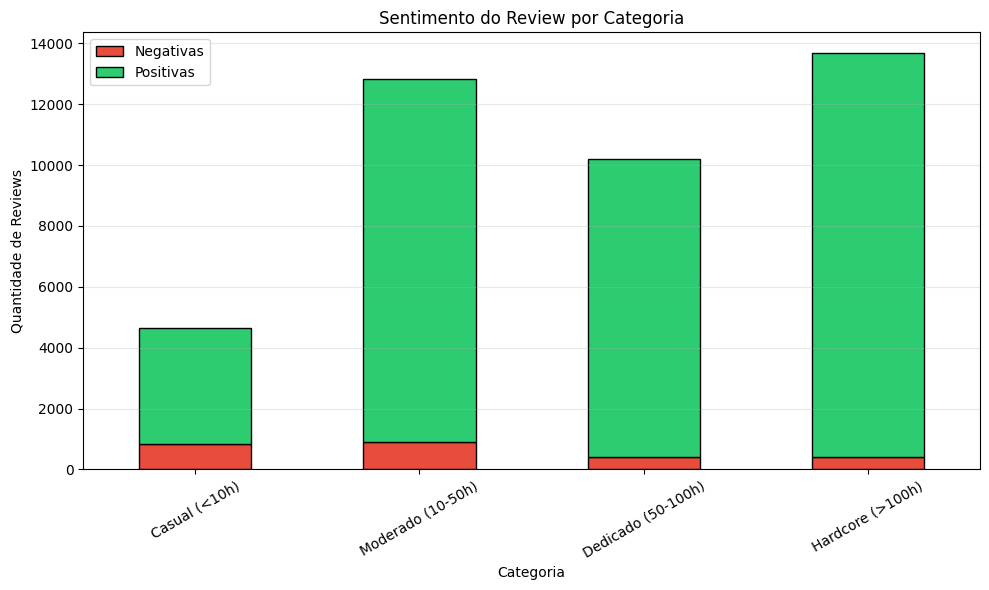

In [ ]:

reviews_by_category = df_translated.groupby(['playtime_category_at_review', 'is_recommended']).size().unstack(fill_value=0)

print("Reviews Positivos x Negativos por Categoria:")
print(reviews_by_category)

categories_order = [
    'Casual (<10h)',
    'Moderado (10-50h)',
    'Dedicado (50-100h)',
    'Hardcore (>100h)'
]

reviews_by_category_ordered = reviews_by_category.reindex(categories_order)
reviews_by_category_ordered.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black'
)

plt.title('Sentimento do Review por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Quantidade de Reviews')
plt.xticks(rotation=30)
plt.legend(['Negativas', 'Positivas'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Média de horas jogadas APÓS o review por categoria:
playtime_category_at_review
Casual (<10h)         33.7
Dedicado (50-100h)    34.9
Desconhecido           NaN
Hardcore (>100h)      45.6
Moderado (10-50h)     40.8
Name: hours_after_review, dtype: float64


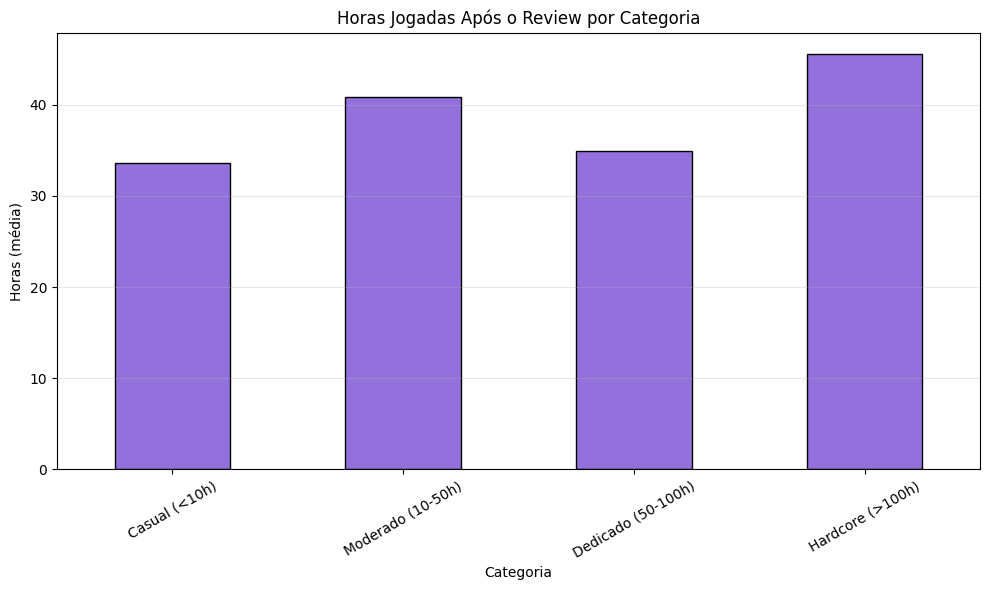

In [ ]:
df_translated['hours_after_review'] = (
    df_translated['total_playtime_hours'] - df_translated['playtime_at_review_hours']
)

mean_hours_after = df_translated.groupby('playtime_category_at_review')['hours_after_review'].mean()

print("\nMédia de horas jogadas APÓS o review por categoria:")
print(mean_hours_after.round(1))

categories_order = [
    'Casual (<10h)',
    'Moderado (10-50h)',
    'Dedicado (50-100h)',
    'Hardcore (>100h)'
]

mean_hours_after_ordered = mean_hours_after.reindex(categories_order)

mean_hours_after_ordered.plot(
    kind='bar',
    figsize=(10,6),
    edgecolor='black',
    color='mediumpurple'
)

plt.title('Horas Jogadas Após o Review por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Horas (média)')
plt.xticks(rotation=30)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

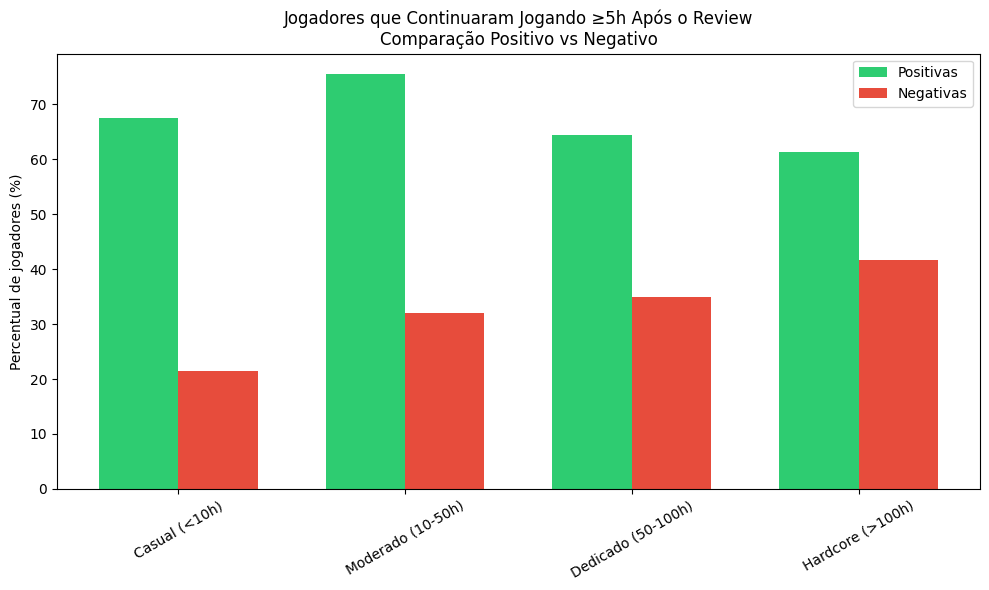

In [ ]:
# -----------------------------
# 1) Calcular horas após review
# -----------------------------
df_translated["hours_after_review"] = (
    df_translated["total_playtime_hours"] - df_translated["playtime_at_review_hours"]
)

df_translated["continue_playing_5h"] = df_translated["hours_after_review"] >= 5


# -----------------------------
# 2) Calcular % para cada grupo
# -----------------------------
df_pos = df_translated[df_translated["is_recommended"] == True]
df_neg = df_translated[df_translated["is_recommended"] == False]

percent_pos = (
    df_pos.groupby("playtime_category_at_review")["continue_playing_5h"].mean() * 100
)
percent_neg = (
    df_neg.groupby("playtime_category_at_review")["continue_playing_5h"].mean() * 100
)


# -----------------------------
# 3) Reordenar categorias
# -----------------------------
order = ["Casual (<10h)", "Moderado (10-50h)", "Dedicado (50-100h)", "Hardcore (>100h)"]
percent_pos = percent_pos.reindex(order)
percent_neg = percent_neg.reindex(order)


# -----------------------------
# 4) Gráfico de barras lado a lado
# -----------------------------
x = np.arange(len(order))       # posições das categorias
width = 0.35                    # largura das barras

plt.figure(figsize=(10, 6))

plt.bar(x - width/2, percent_pos, width, label="Positivas", color="#2ecc71")
plt.bar(x + width/2, percent_neg, width, label="Negativas", color="#e74c3c")

plt.xticks(x, order, rotation=30)
plt.ylabel("Percentual de jogadores (%)")
plt.title("Jogadores que Continuaram Jogando ≥5h Após o Review\nComparação Positivo vs Negativo")
plt.legend()
plt.tight_layout()
plt.show()